# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/hands-on-multimodal-AI/blob/main/hands-on/DEMO_session_02_LongCat_image_edit.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://www.oreilly.com/library/view/transformers-the-definitive/9781098167004/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="Transformers: The Definitive Guide"/>
</a>




# About This Notebook

This notebook demonstrates how to perform **instruction-guided image editing** using the [LongCat-Image-Edit-Turbo](https://huggingface.co/meituan-longcat/LongCat-Image-Edit-Turbo) model via the `diffusers` library from Hugging Face.

Starting from a single input image (`cats_balls.jpeg`), you apply a natural-language prompt (“Turn a cat into a dog”) to generate a semantically consistent edited output. Under the hood, the notebook uses the `LongCatImageEditPipeline`, which supports prompt-based object and concept transformation while preserving the broader scene structure.


The example is intentionally minimal: it focuses on the **core edit loop** (image → prompt → edited image), making it easy to adapt for experimentation, batch processing, or integration into larger multimodal workflows.

Practically, this pattern is useful for:

* Rapid prototyping of image editing ideas
* Building prompt-driven creative tools
* Exploring semantic image manipulation as part of multimodal pipelines (e.g., pairing edits with retrieval or downstream vision-language tasks)



In [ ]:
!pip install git+https://github.com/huggingface/diffusers


  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-o7_vt4lv
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-o7_vt4lv
  Resolved https://github.com/huggingface/diffusers to commit a80b19218b4bd4faf2d6d8c428dcf1ae6f11e43d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.37.0.dev0-py3-none-any.whl size=4930095 sha256=091c6f3ee04ef5b400c13e6f9f12b082c4a619c010f93a5555479f0f2a6024a3
  Stored in directory: /tmp/pip-ephem-wheel-cache-1cxnqwv4/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.36.0
    Uninstalling diffusers-0.36.0:
      Successfully uninstalled diffusers-0.36.0


In [ ]:
import base64
import os
from IPython.display import HTML
from IPython.display import Video
from IPython.display import Image
import torch
from PIL import Image
from diffusers import LongCatImageEditPipeline



def download_files(file_id, destination):
    !gdown --id {file_id} -O {destination}
    if os.path.exists(destination):
        print(f"File downloaded successfully: {destination}")
    else:
        print("Download failed.")

    return Image(filename=destination, width=400)


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1IKjM-BueAJw9xxXpCmQReWeWoKOzhv-j
To: /content/cats_balls.jpeg
100% 1.15M/1.15M [00:00<00:00, 170MB/s]
File downloaded successfully: cats_balls.jpeg


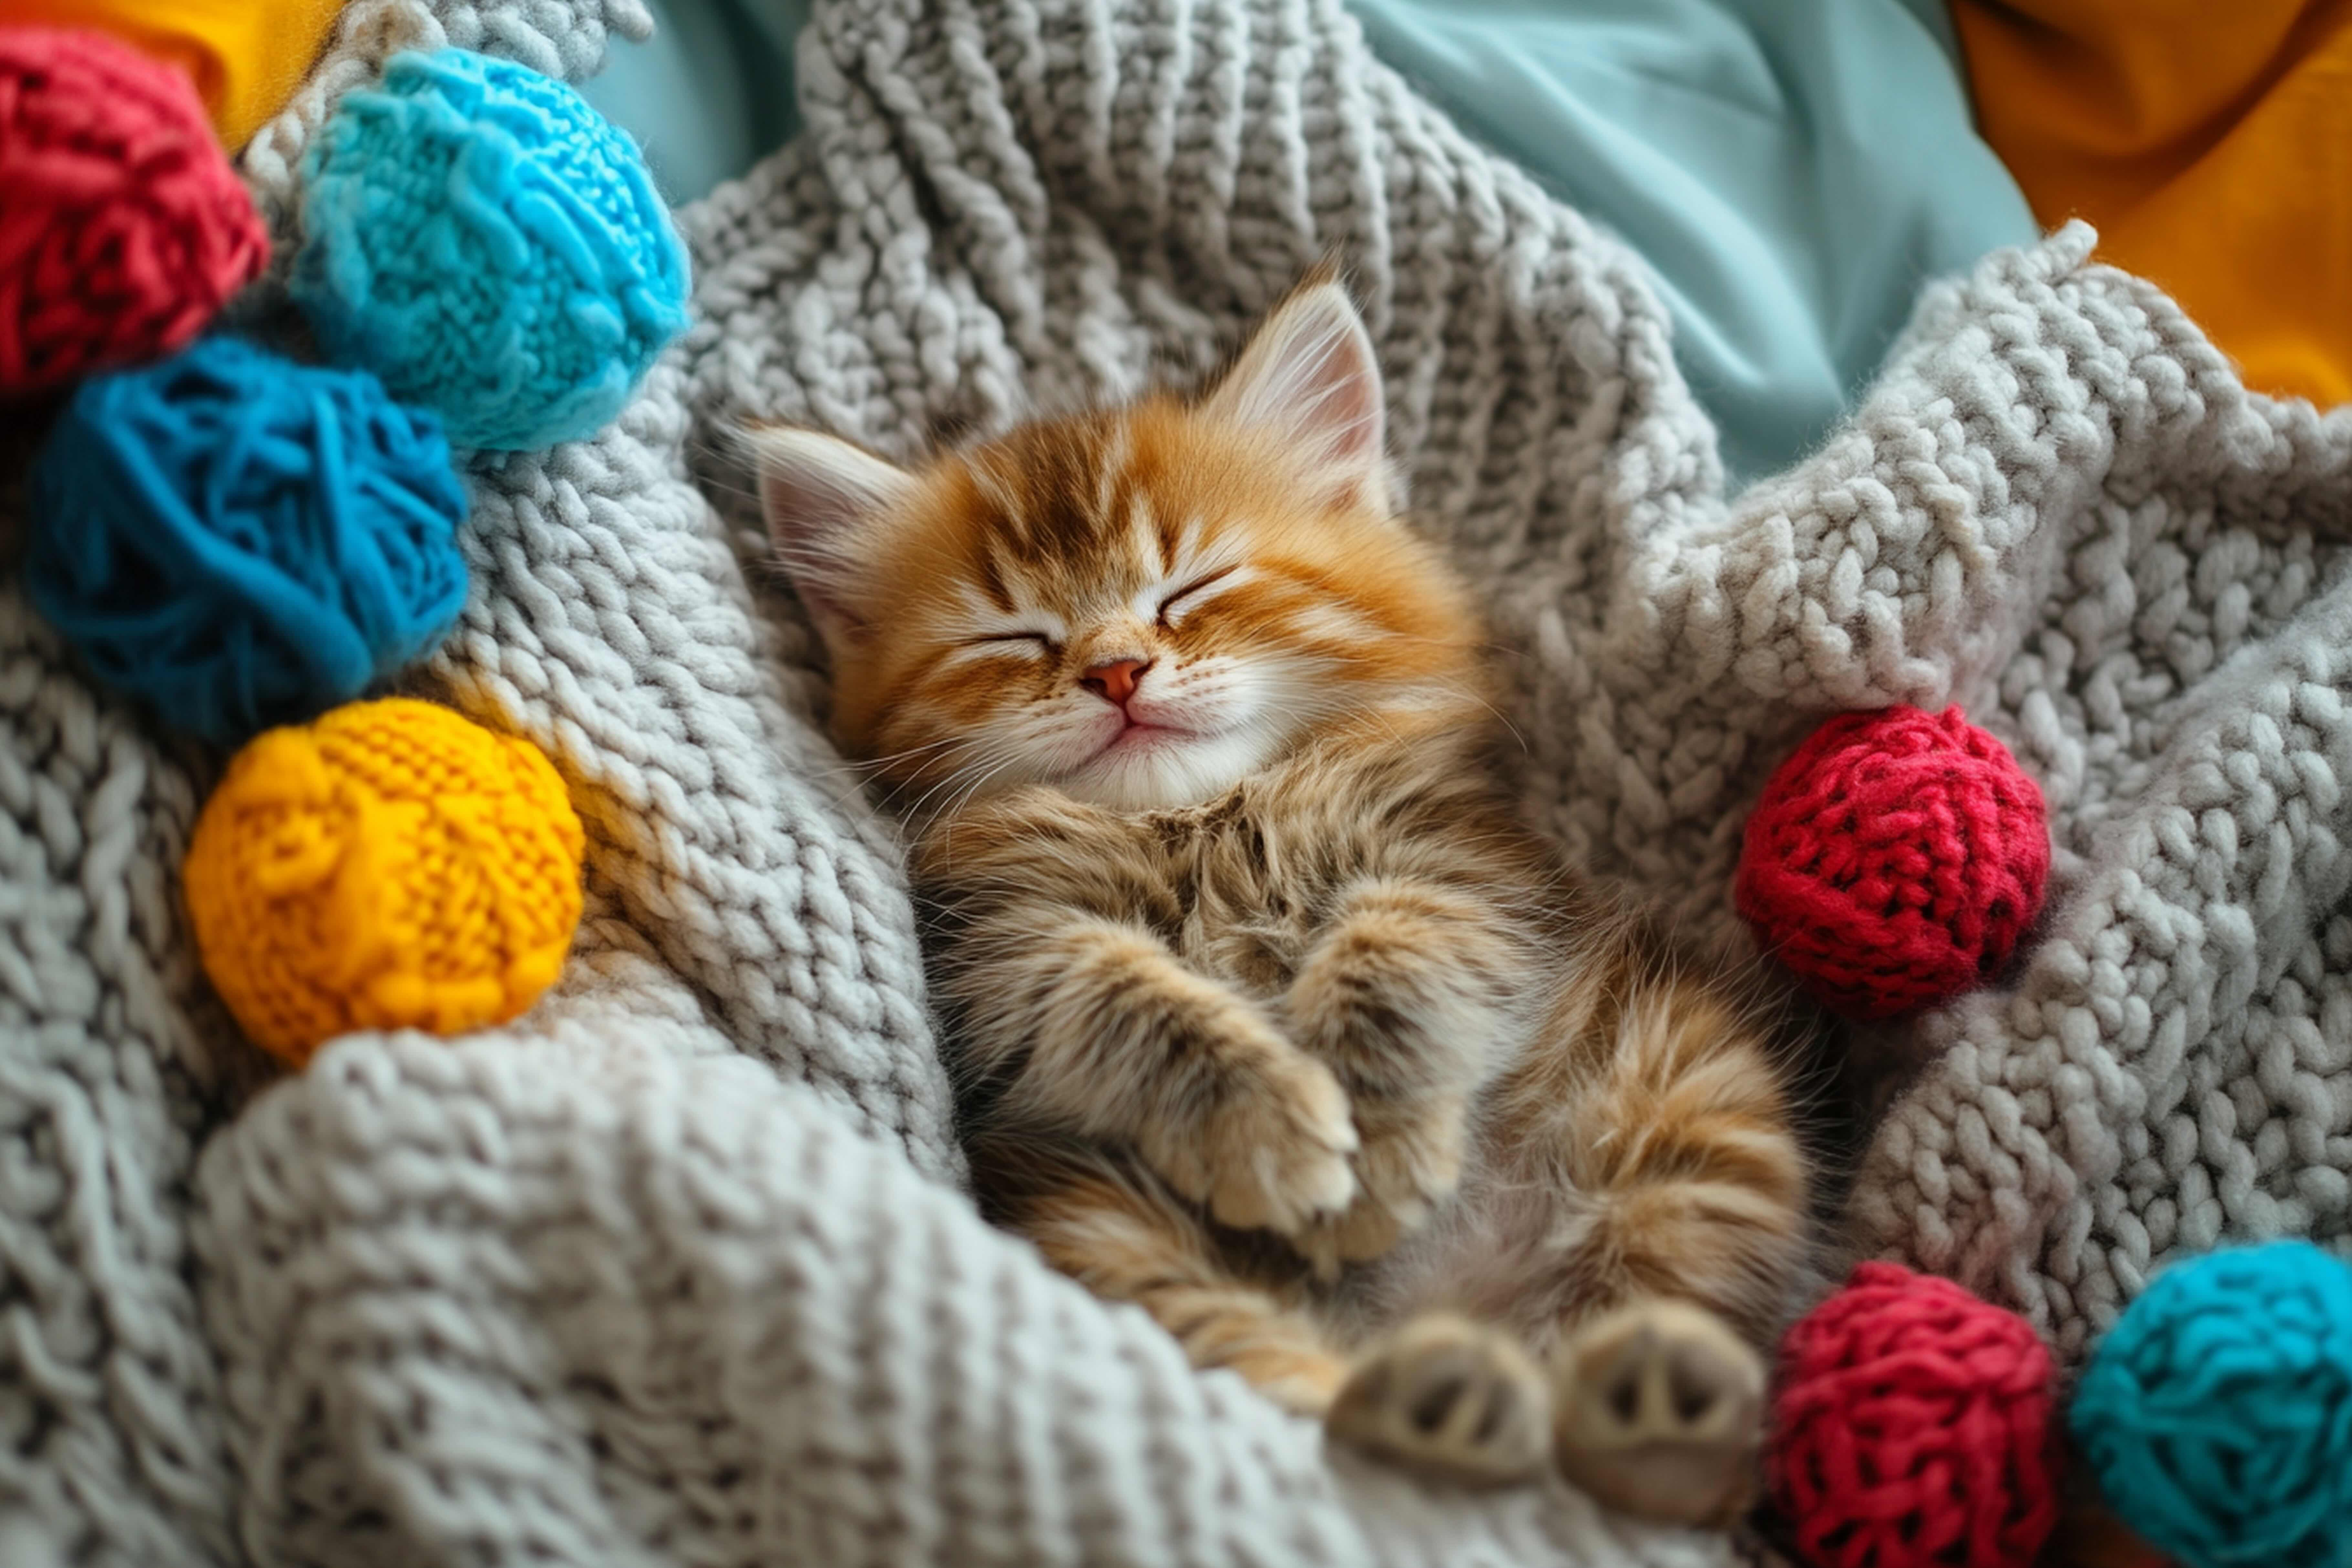

In [ ]:
file_id = "1IKjM-BueAJw9xxXpCmQReWeWoKOzhv-j"
destination = "cats_balls.jpeg"
download_files(file_id, destination)


In [ ]:
device = torch.device('cuda')

pipe = LongCatImageEditPipeline.from_pretrained("meituan-longcat/LongCat-Image-Edit-Turbo", torch_dtype= torch.bfloat16 )
# pipe.to(device, torch.bfloat16)  # Uncomment for high VRAM devices (Faster inference)
pipe.enable_model_cpu_offload()  # Offload to CPU to save VRAM (Required ~18 GB); slower but prevents OOM

img = Image.open('cats_balls.jpeg').convert('RGB')
prompt = 'Turn a cat into a dog'
image = pipe(
    img,
    prompt,
    negative_prompt='',
    guidance_scale=4.5,
    num_inference_steps=50,
    num_images_per_prompt=1,
    generator=torch.Generator("cpu").manual_seed(43)
).images[0]

image.save('edit_example.png')


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

Fetching 29 files:   0%|          | 0/29 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1lET8b5rCaCV9jqvOzjWqKPq21-LT1ltM
To: /content/edit_example.png
100% 1.43M/1.43M [00:00<00:00, 125MB/s]
File downloaded successfully: edit_example.png


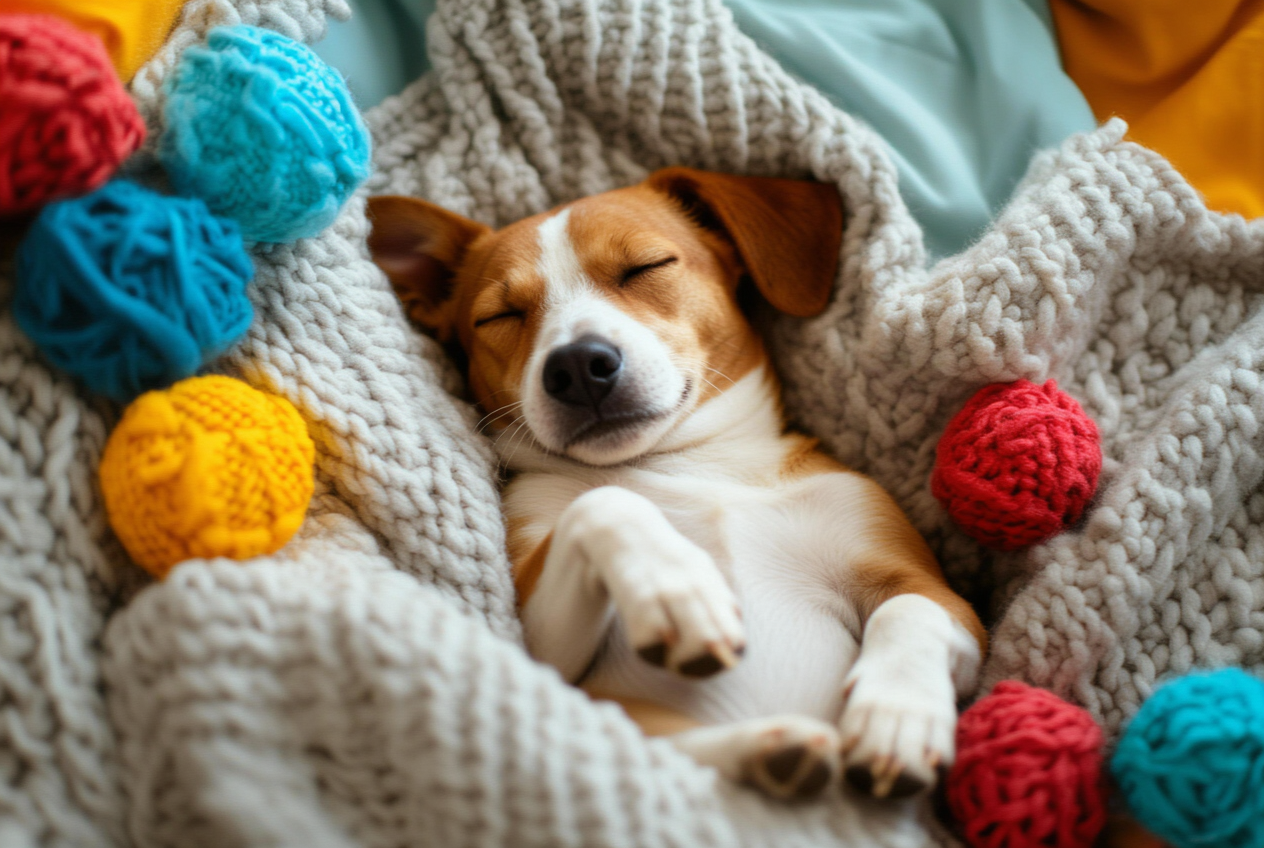

In [ ]:
file_id = "1lET8b5rCaCV9jqvOzjWqKPq21-LT1ltM"
destination = "edit_example.png"
download_files(file_id, destination)
